---
## 1. Importação de Bibliotecas

In [344]:
import pandas as pd
import seaborn as sns
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score, recall_score, f1_score, precision_score,
    classification_report
)
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from sklearn.inspection import permutation_importance
import numpy as np
import shap
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier


---
## 2. Carregamento e visualização inicial dos dados

In [345]:
dados = pd.read_csv("data.csv")
dados.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


In [346]:
dados.shape

(569, 33)

In [347]:
dados.tail()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
564,926424,M,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,...,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115,NaN
565,926682,M,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,...,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637,NaN
566,926954,M,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,...,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820,NaN
567,927241,M,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,...,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400,NaN
568,92751,B,7.76,24.54,47.92,181.0,0.05263,0.04362,0.00000,0.00000,...,30.37,59.16,268.6,0.08996,0.06444,0.0000,0.0000,0.2871,0.07039,NaN


---
## 3. Pre-processamento e preparação dos dados

In [348]:
# Convertendo a coluna "diagnosis" para valores numéricos 1 e 0
# 1 para "M" (maligno) e 0 para "B" (benigno)
dados["diagnosis"] = dados["diagnosis"].map({"M": 1, "B": 0})
dados.tail()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
564,926424,1,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,...,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115,NaN
565,926682,1,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,...,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637,NaN
566,926954,1,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,...,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820,NaN
567,927241,1,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,...,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400,NaN
568,92751,0,7.76,24.54,47.92,181.0,0.05263,0.04362,0.00000,0.00000,...,30.37,59.16,268.6,0.08996,0.06444,0.0000,0.0000,0.2871,0.07039,NaN


In [349]:
#cols_to_drop = dados.columns[dados.columns.str.endswith("_mean") | dados.columns.str.endswith("_worst")| dados.columns.str.startswith("smoothness")| dados.columns.str.startswith("fractal")| dados.columns.str.startswith("texture")| dados.columns.str.startswith("symmetry_se")]
# removendo as colunas id e Unnamed: 32 para evitar confusão no modelo
# id nao tem relacao com o diagnostico, e Unnamed: 32 não tem valores relevantes
dadosParciais = dados.drop(["id", "Unnamed: 32"], axis=1)
correlacao = dadosParciais.corr()
correlacao

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
diagnosis,1.000000,0.730029,0.415185,0.742636,0.708984,0.358560,0.596534,0.696360,0.776614,0.330499,...,0.776454,0.456903,0.782914,0.733825,0.421465,0.590998,0.659610,0.793566,0.416294,0.323872
radius_mean,0.730029,1.000000,0.323782,0.997855,0.987357,0.170581,0.506124,0.676764,0.822529,0.147741,...,0.969539,0.297008,0.965137,0.941082,0.119616,0.413463,0.526911,0.744214,0.163953,0.007066
texture_mean,0.415185,0.323782,1.000000,0.329533,0.321086,-0.023389,0.236702,0.302418,0.293464,0.071401,...,0.352573,0.912045,0.358040,0.343546,0.077503,0.277830,0.301025,0.295316,0.105008,0.119205
perimeter_mean,0.742636,0.997855,0.329533,1.000000,0.986507,0.207278,0.556936,0.716136,0.850977,0.183027,...,0.969476,0.303038,0.970387,0.941550,0.150549,0.455774,0.563879,0.771241,0.189115,0.051019
area_mean,0.708984,0.987357,0.321086,0.986507,1.000000,0.177028,0.498502,0.685983,0.823269,0.151293,...,0.962746,0.287489,0.959120,0.959213,0.123523,0.390410,0.512606,0.722017,0.143570,0.003738
smoothness_mean,0.358560,0.170581,-0.023389,0.207278,0.177028,1.000000,0.659123,0.521984,0.553695,0.557775,...,0.213120,0.036072,0.238853,0.206718,0.805324,0.472468,0.434926,0.503053,0.394309,0.499316
compactness_mean,0.596534,0.506124,0.236702,0.556936,0.498502,0.659123,1.000000,0.883121,0.831135,0.602641,...,0.535315,0.248133,0.590210,0.509604,0.565541,0.865809,0.816275,0.815573,0.510223,0.687382
concavity_mean,0.696360,0.676764,0.302418,0.716136,0.685983,0.521984,0.883121,1.000000,0.921391,0.500667,...,0.688236,0.299879,0.729565,0.675987,0.448822,0.754968,0.884103,0.861323,0.409464,0.514930
concave points_mean,0.776614,0.822529,0.293464,0.850977,0.823269,0.553695,0.831135,0.921391,1.000000,0.462497,...,0.830318,0.292752,0.855923,0.809630,0.452753,0.667454,0.752399,0.910155,0.375744,0.368661
symmetry_mean,0.330499,0.147741,0.071401,0.183027,0.151293,0.557775,0.602641,0.500667,0.462497,1.000000,...,0.185728,0.090651,0.219169,0.177193,0.426675,0.473200,0.433721,0.430297,0.699826,0.438413


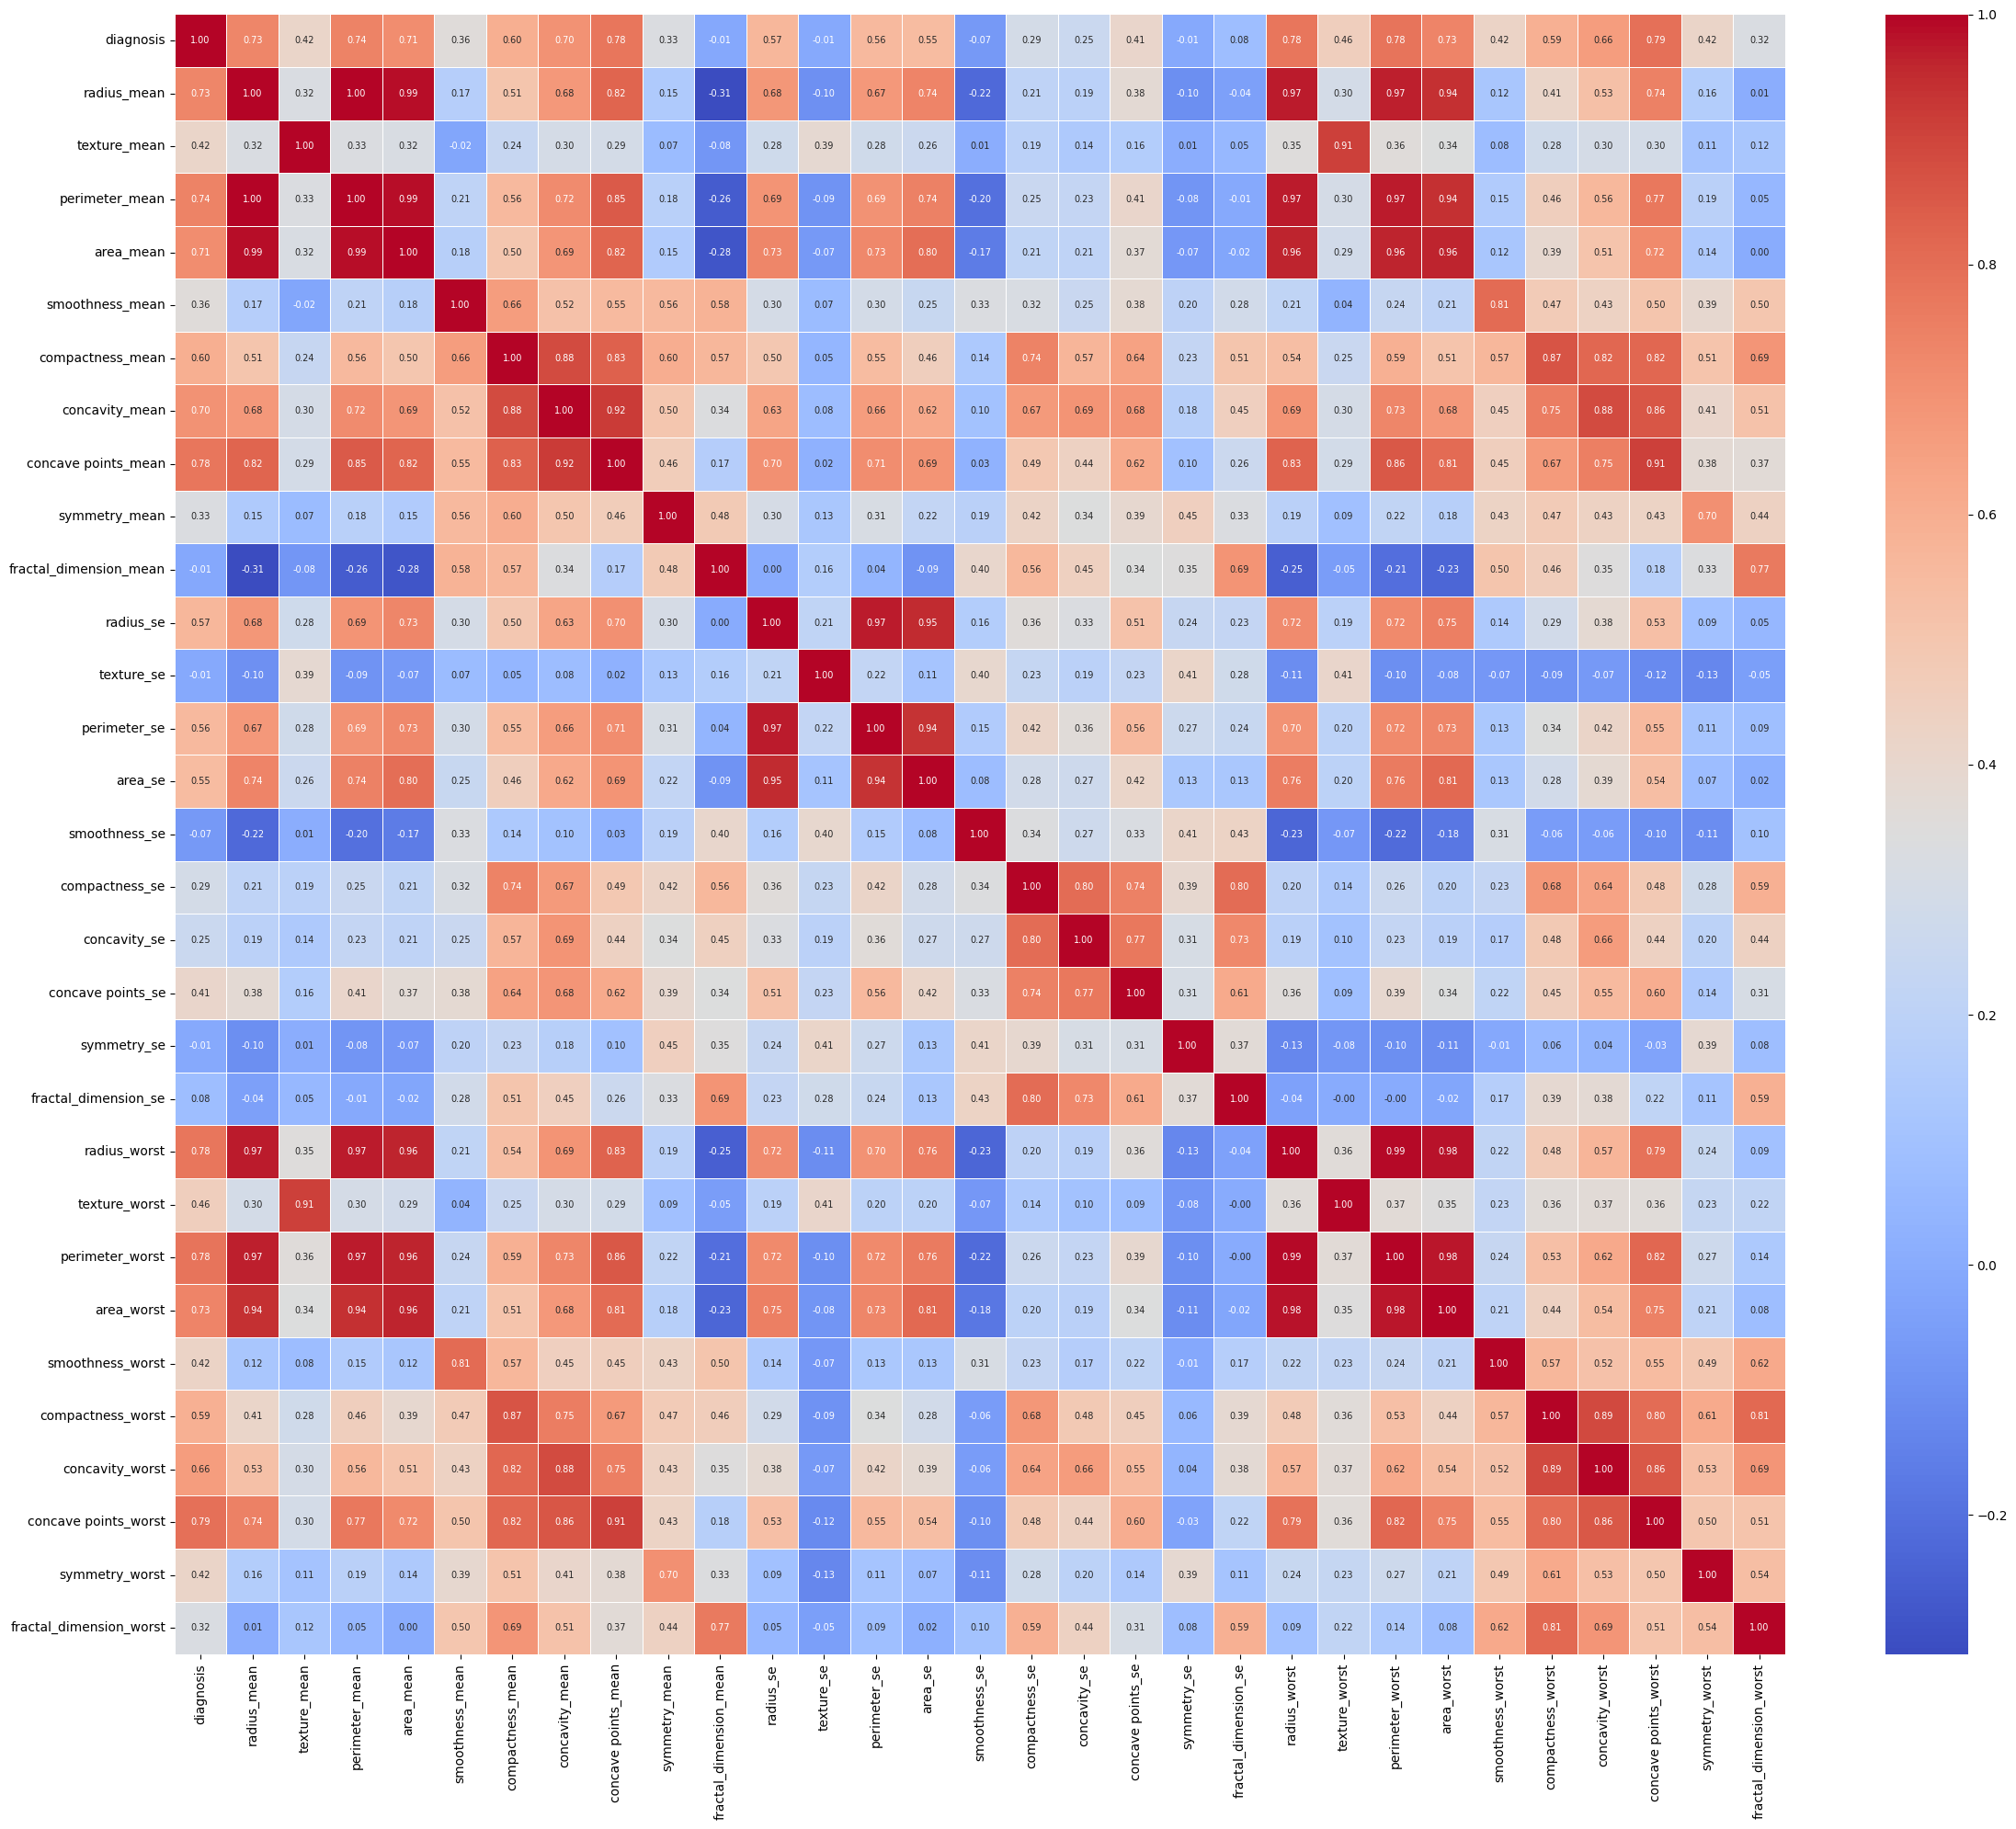

In [350]:
# Visualizando a matriz de correlação usando um heatmap
plt.figure(figsize=(24, 20))
sns.heatmap(correlacao, annot=True, cmap="coolwarm", fmt=".2f", annot_kws={"size": 7}, linewidths=0.5)
plt.tight_layout()
plt.show()

In [351]:
# Preparando os dados para o modelo
X = dadosParciais.drop(columns=["diagnosis"]) # matriz (varias colunas) - sempre maiúsculo
y = dadosParciais.diagnosis # linear (1 coluna) - sempre minúsculo

In [352]:
# Divisão treino/teste (80/20) sem estratificação
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [353]:
# Visualizando dados de treino
X_train

,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
68,9.029,17.33,58.79,250.5,0.10660,0.14130,0.31300,0.04375,0.2111,0.08046,...,10.310,22.65,65.50,324.7,0.14820,0.43650,1.25200,0.17500,0.4228,0.11750
181,21.090,26.57,142.70,1311.0,0.11410,0.28320,0.24870,0.14960,0.2395,0.07398,...,26.680,33.48,176.50,2089.0,0.14910,0.75840,0.67800,0.29030,0.4098,0.12840
63,9.173,13.86,59.20,260.9,0.07721,0.08751,0.05988,0.02180,0.2341,0.06963,...,10.010,19.23,65.59,310.1,0.09836,0.16780,0.13970,0.05087,0.3282,0.08490
248,10.650,25.22,68.01,347.0,0.09657,0.07234,0.02379,0.01615,0.1897,0.06329,...,12.250,35.19,77.98,455.7,0.14990,0.13980,0.11250,0.06136,0.3409,0.08147
60,10.170,14.88,64.55,311.9,0.11340,0.08061,0.01084,0.01290,0.2743,0.06960,...,11.020,17.45,69.86,368.6,0.12750,0.09866,0.02168,0.02579,0.3557,0.08020
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
71,8.888,14.64,58.79,244.0,0.09783,0.15310,0.08606,0.02872,0.1902,0.08980,...,9.733,15.67,62.56,284.4,0.12070,0.24360,0.14340,0.04786,0.2254,0.10840
106,11.640,18.33,75.17,412.5,0.11420,0.10170,0.07070,0.03485,0.1801,0.06520,...,13.140,29.26,85.51,521.7,0.16880,0.26600,0.28730,0.12180,0.2806,0.09097
270,14.290,16.82,90.30,632.6,0.06429,0.02675,0.00725,0.00625,0.1508,0.05376,...,14.910,20.65,94.44,684.6,0.08567,0.05036,0.03866,0.03333,0.2458,0.06120
435,13.980,19.62,91.12,599.5,0.10600,0.11330,0.11260,0.06463,0.1669,0.06544,...,17.040,30.80,113.90,869.3,0.16130,0.35680,0.40690,0.18270,0.3179,0.10550


---
## 4. Treinando os modelos

In [354]:
results = {}

#model = SVC(kernel="rbf", C=1.0, gamma="scale")
model = SVC(kernel="linear", C=2, class_weight={0:1, 1:5})

# =========================
# 4.1. Treinar
# =========================
model.fit(X_train, y_train)

# =========================
# 4.2. Prever
# =========================
y_pred = model.predict(X_test)

# =========================
# 4.3. Avaliar
# =========================
print("Acurácia:", accuracy_score(y_test, y_pred))
print("\nRelatório:\n", classification_report(y_test, y_pred))

results["SVC Linear"] = {
    'accuracy': accuracy_score(y_test, y_pred),
    'recall': recall_score(y_test, y_pred),
    'precision': precision_score(y_test, y_pred),
    'f1': f1_score(y_test, y_pred),
}

Acurácia: 0.9385964912280702

Relatório:
               precision    recall  f1-score   support

           0       0.98      0.92      0.95        71
           1       0.88      0.98      0.92        43

    accuracy                           0.94       114
   macro avg       0.93      0.95      0.94       114
weighted avg       0.94      0.94      0.94       114



In [355]:
for i in range(10):
    entrada = X_test.iloc[i:i+1]
    real = y_test.iloc[i]
    pred = model.predict(entrada)[0]

    print(f"Real: {real} | Pred: {pred}")

Real: 0 | Pred: 0
Real: 1 | Pred: 1
Real: 1 | Pred: 1
Real: 0 | Pred: 0
Real: 0 | Pred: 0
Real: 1 | Pred: 1
Real: 1 | Pred: 1
Real: 1 | Pred: 1
Real: 0 | Pred: 0
Real: 0 | Pred: 0


In [356]:
model_1 = LinearRegression()

# =========================
# 4.4. Treinar
# =========================
model_1.fit(X_train, y_train)

# =========================
# 4.5. Prever
# =========================
# TODO: O predict desse modelo está causando warnings de divisão por zero e number overflow
y_pred_1 = model_1.predict(X_test)
y_pred_1_classes = (y_pred_1 >= 0.5).astype(int)

# =========================
# 4.6. Avaliar
# =========================
print("Acurácia:", accuracy_score(y_test, y_pred_1_classes))
print("Relatório:", classification_report(y_test, y_pred_1_classes))

results["Linear Regression"] = {
    'accuracy': accuracy_score(y_test, y_pred_1_classes),
    'recall': recall_score(y_test, y_pred_1_classes),
    'precision': precision_score(y_test, y_pred_1_classes),
    'f1': f1_score(y_test, y_pred_1_classes),
}

Acurácia: 0.956140350877193
Relatório:               precision    recall  f1-score   support

           0       0.95      0.99      0.97        71
           1       0.97      0.91      0.94        43

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



/Users/pedroguerreiro/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Users/pedroguerreiro/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Users/pedroguerreiro/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: invalid value encountered in matmul
  return X @ coef_ + self.intercept_


In [357]:
model_2 = DecisionTreeClassifier(max_depth=5, random_state=42)

# =========================
# 4.7. Treinar
# =========================
model_2.fit(X_train, y_train)

# =========================
# 4.8. Prever
# =========================
y_pred_2 = model_2.predict(X_test)

# =========================
# 4.9. Avaliar
# =========================
print('Acuracia:', accuracy_score(y_test, y_pred_2))
print('Relatorio:', classification_report(y_test, y_pred_2))

results['Decision Tree'] = {
    'accuracy': accuracy_score(y_test, y_pred_2),
    'recall': recall_score(y_test, y_pred_2),
    'precision': precision_score(y_test, y_pred_2),
    'f1': f1_score(y_test, y_pred_2),
}


Acuracia: 0.9473684210526315
Relatorio:               precision    recall  f1-score   support

           0       0.96      0.96      0.96        71
           1       0.93      0.93      0.93        43

    accuracy                           0.95       114
   macro avg       0.94      0.94      0.94       114
weighted avg       0.95      0.95      0.95       114



In [358]:
model_3 = LogisticRegression(max_iter=10000, random_state=42, class_weight={0:1, 1:5})

# =========================
# 4.10. Treinar
# =========================
model_3.fit(X_train, y_train)

# =========================
# 4.11. Prever
# =========================
y_pred_3 = model_3.predict(X_test)

# =========================
# 4.12. Avaliar
# =========================
print('Acuracia:', accuracy_score(y_test, y_pred_3))
print('Relatorio:', classification_report(y_test, y_pred_3))

results['Logistic Regression'] = {
    'accuracy': accuracy_score(y_test, y_pred_3),
    'recall': recall_score(y_test, y_pred_3),
    'precision': precision_score(y_test, y_pred_3),
    'f1': f1_score(y_test, y_pred_3),
}

/Users/pedroguerreiro/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/pedroguerreiro/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/pedroguerreiro/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/pedroguerreiro/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:330: RuntimeWarning: divide by zero encountered in matmul
  grad[:n_features] = X.T @ grad_pointwise + l2_reg_strength * weights
/Users/pedroguerreiro/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:330: RuntimeWarning: overflow encountered in matmul
  grad[:

Acuracia: 0.9736842105263158
Relatorio:               precision    recall  f1-score   support

           0       0.99      0.97      0.98        71
           1       0.95      0.98      0.97        43

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114



/Users/pedroguerreiro/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/pedroguerreiro/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/pedroguerreiro/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


In [359]:
model_4 = KNeighborsClassifier(n_neighbors=5)

# =========================
# 4.13. Treinar
# =========================
model_4.fit(X_train, y_train)

# =========================
# 4.14. Prever
# =========================
y_pred_4 = model_4.predict(X_test)

# =========================
# 4.15. Avaliar
# =========================
print('Acuracia:', accuracy_score(y_test, y_pred_4))
print('Relatorio:', classification_report(y_test, y_pred_4))

results['KNN'] = {
    'accuracy': accuracy_score(y_test, y_pred_4),
    'recall': recall_score(y_test, y_pred_4),
    'precision': precision_score(y_test, y_pred_4),
    'f1': f1_score(y_test, y_pred_4),
}

Acuracia: 0.956140350877193
Relatorio:               precision    recall  f1-score   support

           0       0.93      1.00      0.97        71
           1       1.00      0.88      0.94        43

    accuracy                           0.96       114
   macro avg       0.97      0.94      0.95       114
weighted avg       0.96      0.96      0.96       114



---
## 5. Comparação de resultado dos modelos

In [360]:
# entrada = dict(zip(X_train.columns, X_test.iloc[0]))
# print("Entrada de exemplo:", entrada)

# pred_raw = model_1.predict(X_test.iloc[0:1])[0]
# pred_class = int(pred_raw >= 0.5)
# print(f"Valor bruto: {pred_raw:.4f} | Classe prevista: {pred_class} | Real: {y_test.iloc[0]}")

metrics_df = pd.DataFrame([
    {
        'Modelo': name,
        'Acurácia': f"{v['accuracy']:.4f}",
        'Recall': f"{v['recall']:.4f}",
        'Precisão': f"{v['precision']:.4f}",
        'F1-Score': f"{v['f1']:.4f}",
    }
    for name, v in results.items()
])
metrics_df

,Modelo,Acurácia,Recall,Precisão,F1-Score
0,SVC Linear,0.9386,0.9767,0.8750,0.9231
1,Linear Regression,0.9561,0.9070,0.9750,0.9398
2,Decision Tree,0.9474,0.9302,0.9302,0.9302
3,Logistic Regression,0.9737,0.9767,0.9545,0.9655
4,KNN,0.9561,0.8837,1.0000,0.9383


---
## 6. Visualização das decisões dos modelos

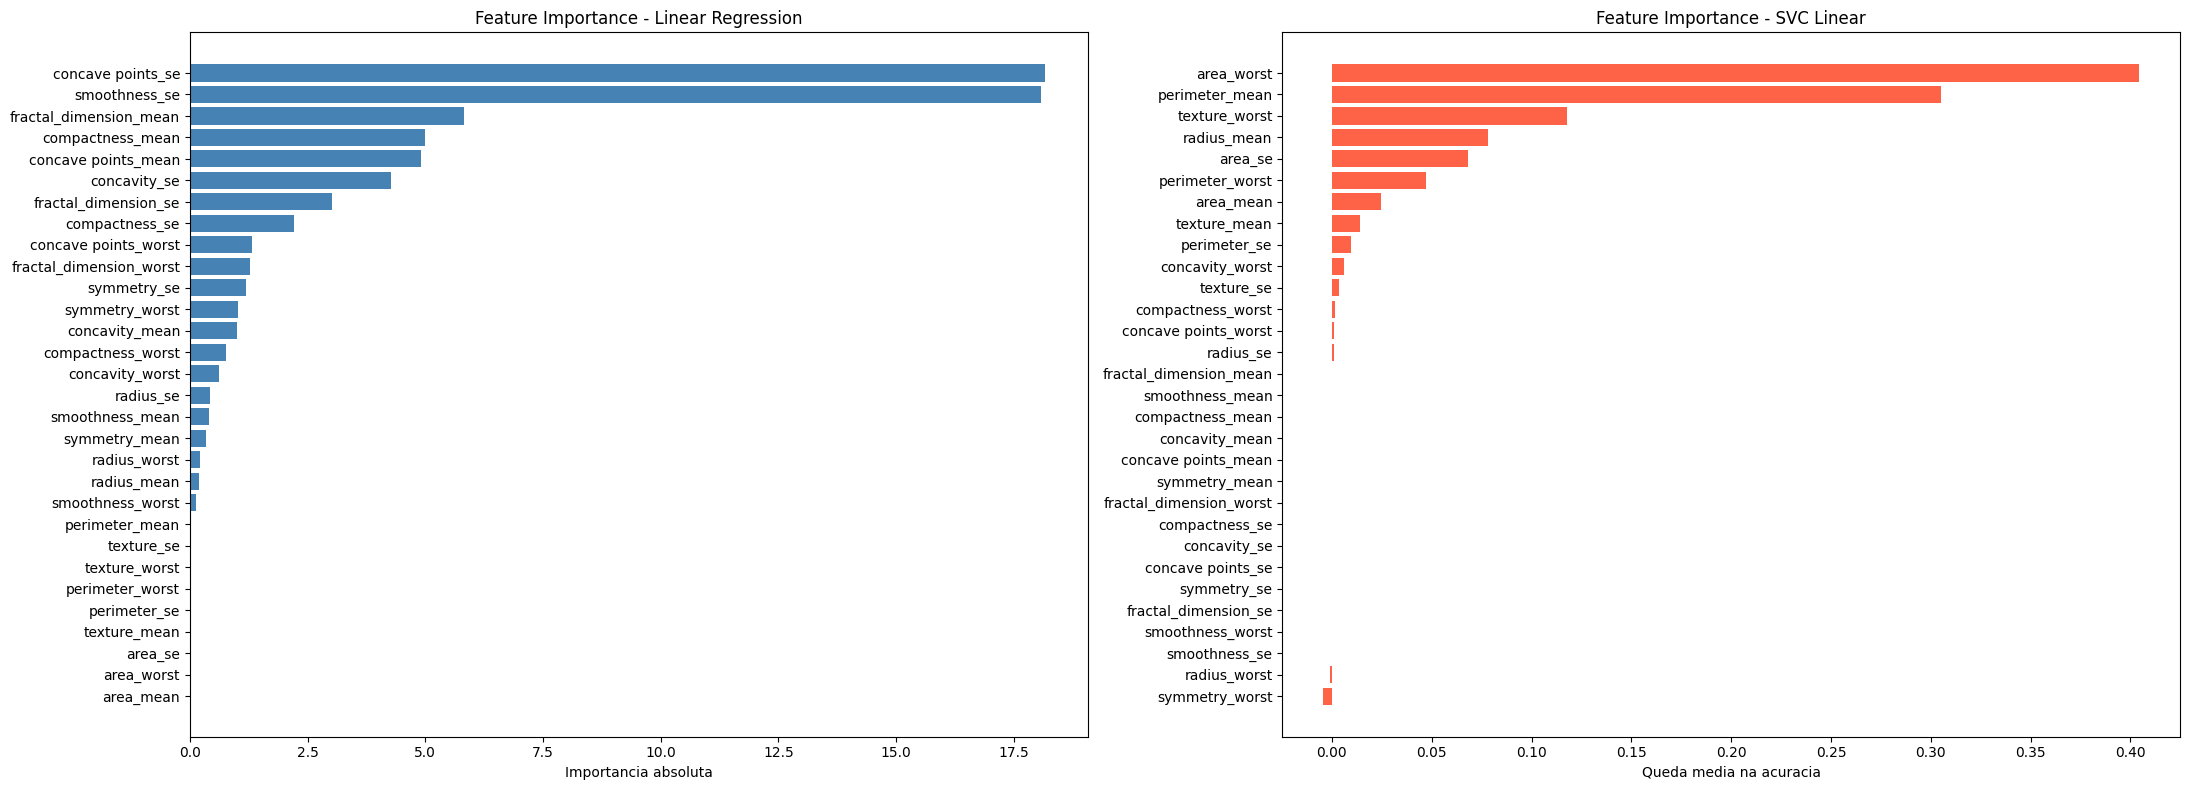

In [361]:
feature_names = X_train.columns.tolist()

# LinearRegression: coeficientes como importancia
lr_importance = np.abs(model_1.coef_)
lr_order = np.argsort(lr_importance)[::-1]

# SVC (Linear): permutation importance
perm = permutation_importance(model, X_test, y_test, n_repeats=10, random_state=42)
svc_importance = perm.importances_mean
svc_order = np.argsort(svc_importance)[::-1]

fig, axes = plt.subplots(1, 2, figsize=(22, 8))

axes[0].barh(
    [feature_names[i] for i in lr_order],
    lr_importance[lr_order],
    color='steelblue'
)
axes[0].invert_yaxis()
axes[0].set_title('Feature Importance - Linear Regression')
axes[0].set_xlabel('Importancia absoluta')

axes[1].barh(
    [feature_names[i] for i in svc_order],
    svc_importance[svc_order],
    color='tomato'
)
axes[1].invert_yaxis()
axes[1].set_title('Feature Importance - SVC Linear')
axes[1].set_xlabel('Queda media na acuracia')

plt.tight_layout()
plt.show()

=== SHAP - Linear Regression ===


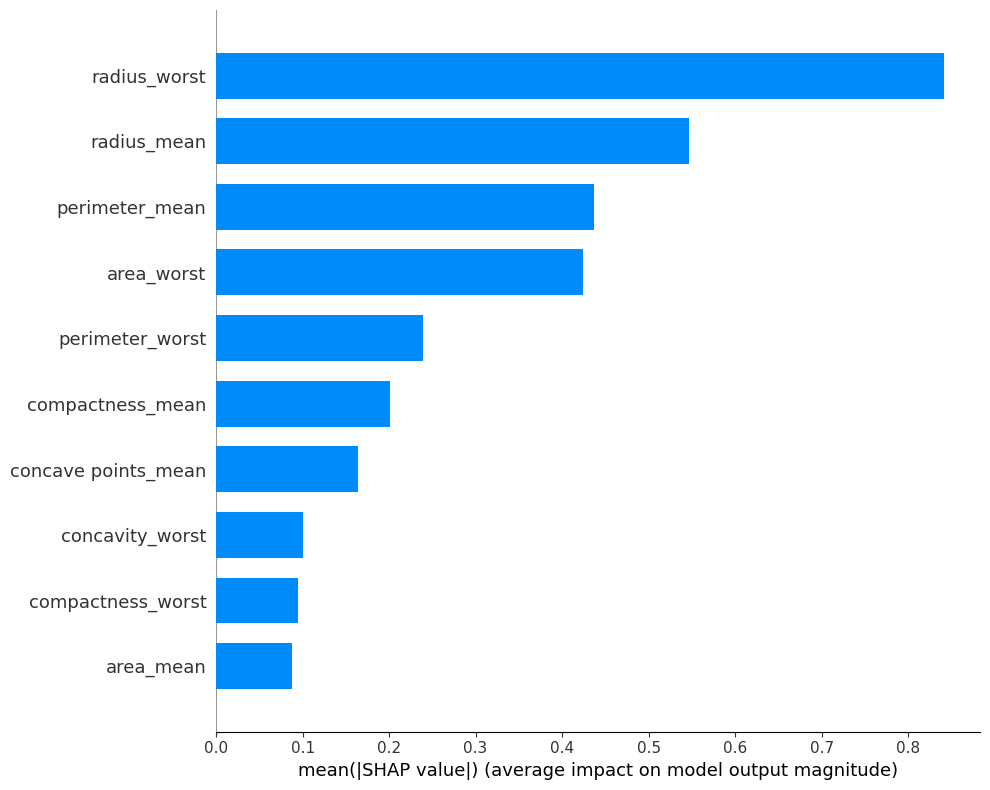

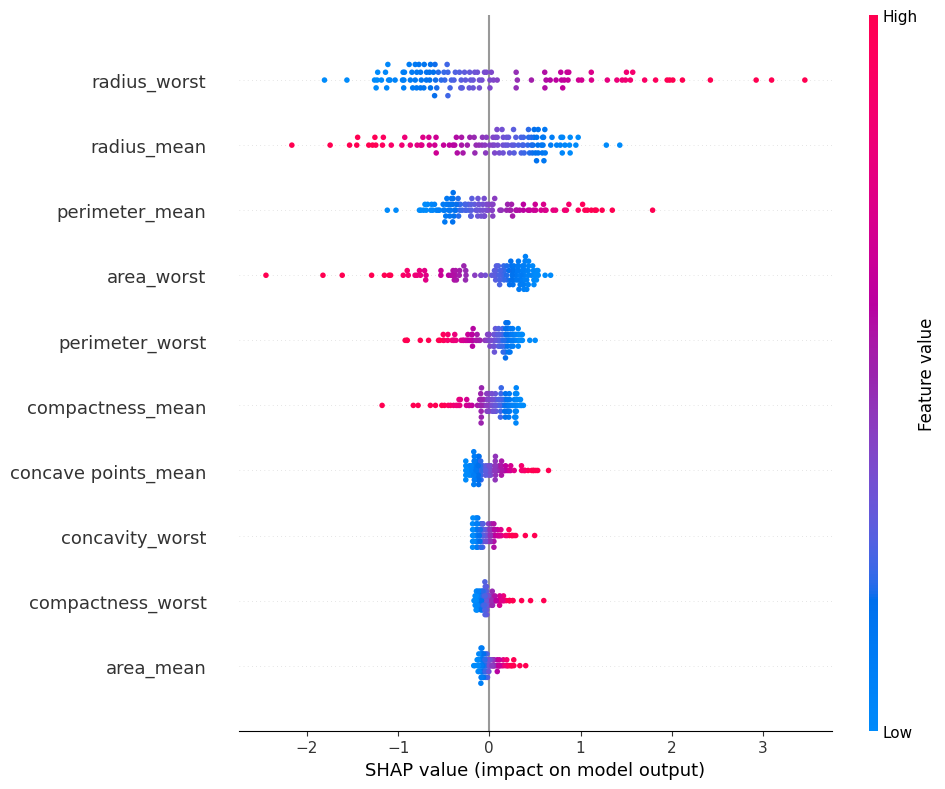

In [362]:
# SHAP - Linear Regression
lr_explainer = shap.LinearExplainer(model_1, X_train)
lr_shap_values = lr_explainer.shap_values(X_test)

print('=== SHAP - Linear Regression ===')
shap.summary_plot(lr_shap_values, X_test, plot_type='bar', title='SHAP - Linear Regression (importancia media)', max_display=10, plot_size=(10,8))
shap.summary_plot(lr_shap_values, X_test, title='SHAP - Linear Regression (impacto por amostra)', max_display=10, plot_size=(10,8))

# SHAP - SVC 
# TODO: esse modelo gera warnings de divisão por zero e number overflow
# background = shap.sample(X_train, 100, random_state=42)
# svc_explainer = shap.KernelExplainer(model.predict, background)
# svc_shap_values = svc_explainer.shap_values(X_test.iloc[:50], nsamples=100)

# print('=== SHAP - SVC Linear ===')
# shap.summary_plot(svc_shap_values, X_test.iloc[:50], plot_type='bar', title='SHAP - SVC Linear (importancia media)', max_display=10, plot_size=(10,8))
# shap.summary_plot(svc_shap_values, X_test.iloc[:50], title='SHAP - SVC Linear (impacto por amostra)', max_display=10, plot_size=(10,8))